In [ ]:
import socket
import time
import random
import csv
import numpy as np

HOST = 'localhost'
PORT = 8000
NUM_ORDERS = 100000

import threading

NUM_THREADS = 1

thread_rtts = [[] for _ in range(NUM_THREADS)]
thread_type_rtts = [{"NEW": [], "MODIFY": [], "CANCEL": []} for _ in range(NUM_THREADS)]

# Split work exactly across threads so total generated orders equals NUM_ORDERS.
thread_order_counts = [NUM_ORDERS // NUM_THREADS] * NUM_THREADS
for i in range(NUM_ORDERS % NUM_THREADS):
    thread_order_counts[i] += 1

def generate_thread_requests(thread_id, num_orders):
    rng = random.Random(12345 + thread_id)
    order_ids = []
    next_order_id = thread_id * 1_000_000 + 1
    requests = []

    for _ in range(num_orders):
        order_type = rng.choices(["NEW", "MODIFY", "CANCEL"], weights=[0.7, 0.2, 0.1])[0]
        symbol = rng.choice(["NVDA", "AAPL", "TSLA"])
        side_tag = "1" if rng.choice(["BUY", "SELL"]) == "BUY" else "2"

        if order_type == "NEW" or not order_ids:
            order = (
                f"8=FIX.4.2|35=D|11={next_order_id}|55={symbol}|54={side_tag}|"
                f"44={rng.randint(90000, 110000)}|38={rng.randint(1, 10)}|"
            )
            order_ids.append(next_order_id)
            next_order_id += 1
        elif order_type == "MODIFY":
            oid = rng.choice(order_ids)
            order = (
                f"8=FIX.4.2|35=G|11={oid}|55={symbol}|54={side_tag}|"
                f"44={rng.randint(90000, 110000)}|38={rng.randint(1, 10)}|"
            )
        else:  # CANCEL
            oid = rng.choice(order_ids)
            order = f"8=FIX.4.2|35=F|11={oid}|"
            order_ids.remove(oid)

        requests.append((order_type, order.encode()))

    return requests

# Pre-generate all thread requests outside timed section.
thread_requests = [
    generate_thread_requests(thread_id, thread_order_counts[thread_id])
    for thread_id in range(NUM_THREADS)
]

def thread_worker(thread_id):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.connect((HOST, PORT))

        for order_type, msg in thread_requests[thread_id]:
            t0 = time.time_ns()
            s.sendall(msg)
            response = s.recv(4096)
            t1 = time.time_ns()
            rtt_us = (t1 - t0) // 1000
            thread_rtts[thread_id].append(rtt_us)
            thread_type_rtts[thread_id][order_type].append(rtt_us)

threads = []
start_time = time.time_ns()
for i in range(NUM_THREADS):
    t = threading.Thread(target=thread_worker, args=(i,))
    t.start()
    threads.append(t)

for t in threads:
    t.join()

end_time = time.time_ns()
total_time_s = (end_time - start_time) / 1e9

# Combine results
all_rtts = [rtt for sublist in thread_rtts for rtt in sublist]
all_type_rtts = {"NEW": [], "MODIFY": [], "CANCEL": []}
for d in thread_type_rtts:
    for typ in all_type_rtts:
        all_type_rtts[typ].extend(d[typ])

completed_orders = len(all_rtts)
throughput = completed_orders / total_time_s if total_time_s > 0 else float("inf")

print(f"Generated orders: {sum(thread_order_counts)}")
print(f"Total orders sent: {completed_orders}")
print(f"Mean RTT: {np.mean(all_rtts):.2f}us")
print(f"Throughput: {throughput:.2f} orders/sec")

KeyboardInterrupt: 

Exception in thread Thread-4 (thread_worker):
Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_80303/3867291020.py", line 69, in thread_worker
ConnectionResetError: [Errno 104] Connection reset by peer


Connect to Server and generate random orders

Throughput: 7817.41 orders/second
ALL: count=500000, mean=127.92us, p95=162.00us, p99=232.00us, max=2268568.00us
NEW: count=350008, mean=133.08us, p95=152.00us, p99=195.00us, max=2268568.00us
MODIFY: count=99923, mean=105.19us, p95=140.00us, p99=180.00us, max=4055.00us
CANCEL: count=50069, mean=137.19us, p95=244.00us, p99=321.00us, max=8375.00us


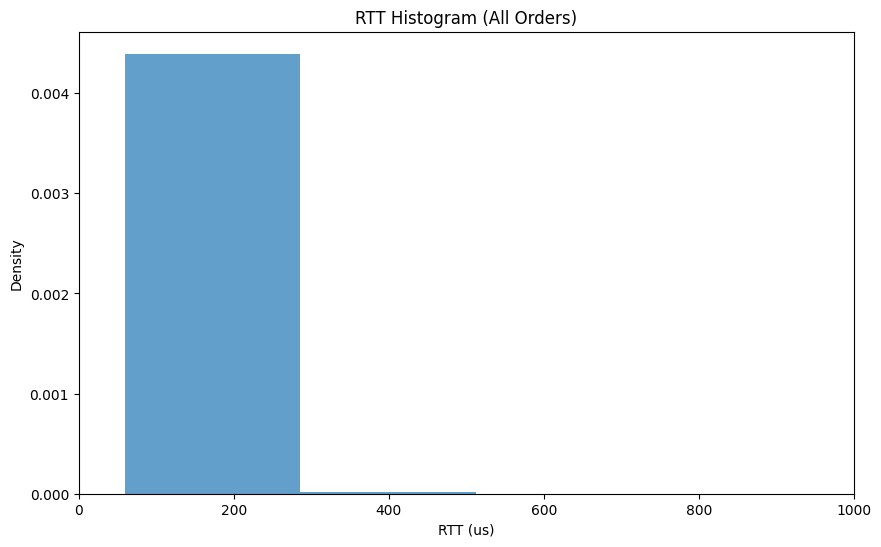

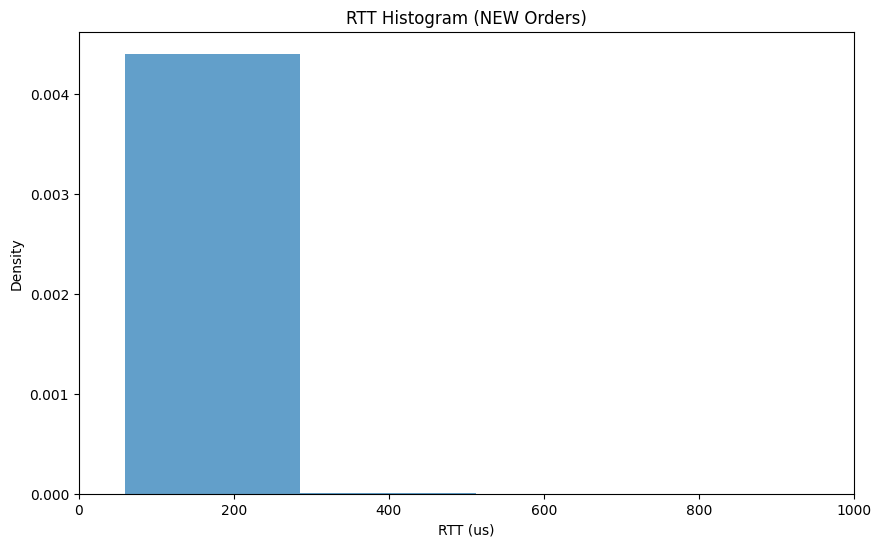

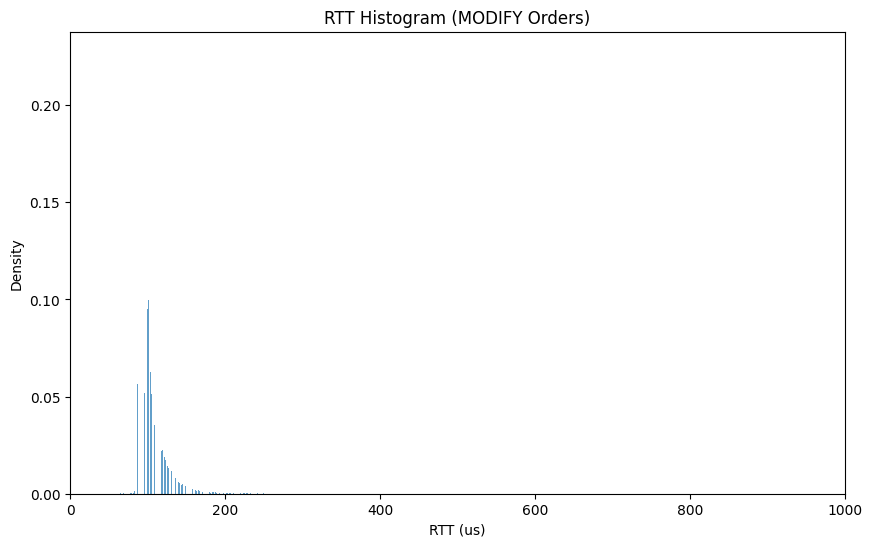

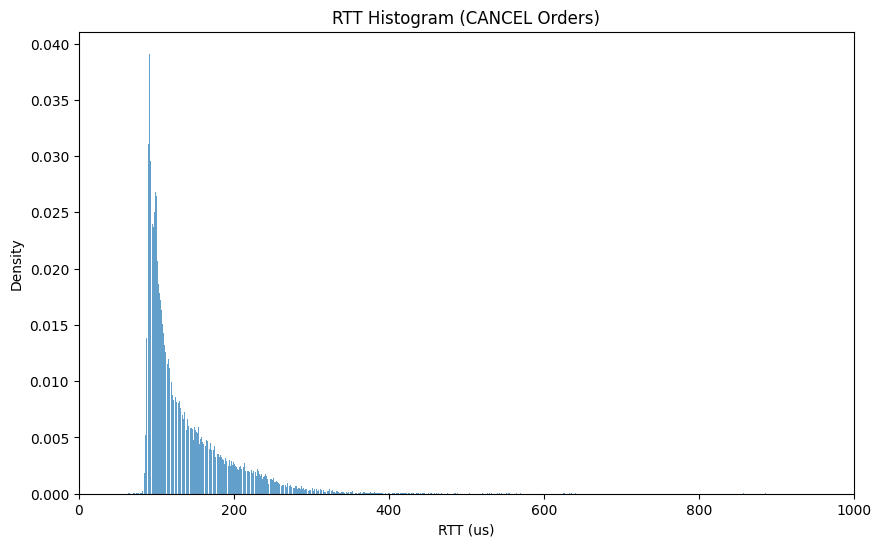

In [17]:

# Print metrics
print(f"Throughput: {throughput:.2f} orders/second")

import numpy as np
def print_stats(name, data):
    arr = np.array(data)
    print(f"{name}: count={len(arr)}, mean={arr.mean():.2f}us, p95={np.percentile(arr,95):.2f}us, p99={np.percentile(arr,99):.2f}us, max={arr.max():.2f}us")

print_stats("ALL", all_rtts)
for typ in all_type_rtts:
    print_stats(typ, all_type_rtts[typ])

import matplotlib.pyplot as plt

# Histogram for all RTTs with log scale and limited x-axis
plt.figure(figsize=(10,6))
plt.hist(all_rtts, bins=10000, alpha=0.7, density=True)
plt.title("RTT Histogram (All Orders)")
plt.xlabel("RTT (us)")
plt.ylabel("Density")
plt.xlim(0, 1000)  # Focus on main range, adjust as needed
plt.yscale('linear')  # Or use 'log' for y if needed
plt.show()

# Histogram for each type with log scale and limited x-axis
for typ in all_type_rtts:
    plt.figure(figsize=(10,6))
    plt.hist(all_type_rtts[typ], bins=10000, alpha=0.7, density=True)
    plt.title(f"RTT Histogram ({typ} Orders)")
    plt.xlabel("RTT (us)")
    plt.ylabel("Density")
    plt.xlim(0, 1000)  # Adjust as needed
    plt.show()
